In [1]:
%pip install duckdb jupysql pandas matplotlib duckdb-engine

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import sqlite3
import duckdb
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from category_encoders import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from category_encoders import OrdinalEncoder
from sklearn.pipeline import Pipeline
# Set display options
pd.set_option('display.max_columns', None)

---
### Exploratory data Analysis (EDA)

In [3]:
conn = sqlite3.connect('./nepal.sqlite')

# Query caste distribution by district
query = """
    SELECT i.district_id, h.caste_household, COUNT(*) as count
    FROM household_demographics h
    JOIN id_map i ON h.household_id = i.household_id
    GROUP BY i.district_id, h.caste_household
    ORDER BY i.district_id, count DESC
"""

df_caste = pd.read_sql_query(query, conn)
conn.close()

# Show top 3 castes per district
for district in [1, 2, 3, 4]:
    print(f"\nDistrict {district}:")
    top_castes = df_caste[df_caste['district_id'] == district].head(3)
    for _, row in top_castes.iterrows():
        print(f"  {row['caste_household']}: {row['count']:,} households")


District 1:
  Chhetree: 8,943 households
  Brahman-Hill: 4,123 households
  Rai: 4,119 households

District 2:
  Chhetree: 15,312 households
  Tamang: 11,927 households
  Newar: 7,451 households

District 3:
  Tamang: 28,402 households
  Brahman-Hill: 19,183 households
  Chhetree: 10,867 households

District 4:
  Gurung: 15,119 households
  Brahman-Hill: 13,043 households
  Chhetree: 8,766 households


In [4]:
# 1. Connect to the SQLite database
conn = sqlite3.connect('./nepal.sqlite')

# 2. Query to get all table names
tables_df = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
table_names_list = tables_df['name'].tolist()

# 3. Close the connection
conn.close()

print(f"Tables in database: {table_names_list}")

Tables in database: ['building_structure', 'building_damage', 'household_demographics', 'id_map']


In [5]:
conn = sqlite3.connect('./nepal.sqlite')

df_sqlite_head = pd.read_sql_query("SELECT * FROM building_structure LIMIT 5", conn)

conn.close()
print(df_sqlite_head)

   building_id  count_floors_pre_eq  count_floors_post_eq  age_building  \
0            1                    1                     1             9   
1            2                    1                     1            15   
2            3                    1                     1            20   
3            4                    1                     1            20   
4            5                    1                     1            30   

   plinth_area_sq_ft  height_ft_pre_eq  height_ft_post_eq  \
0                288                 9                  9   
1                364                 9                  9   
2                384                 9                  9   
3                312                 9                  9   
4                308                 9                  9   

  land_surface_condition foundation_type                 roof_type  \
0                   Flat           Other  Bamboo/Timber-Light roof   
1                   Flat           Other  

In [6]:
conn = sqlite3.connect('./nepal.sqlite')

df_sqlite_columns = pd.read_sql_query("""
    SELECT building_id, age_building
    FROM building_structure
    LIMIT 5
""", conn)

conn.close()
print(df_sqlite_columns)

   building_id  age_building
0            1             9
1            2            15
2            3            20
3            4            20
4            5            30


In [7]:
conn = sqlite3.connect('./nepal.sqlite')

count_df = pd.read_sql_query(
    "SELECT COUNT(*) as count FROM building_structure",
    conn
)
total_buildings_sqlite = count_df.loc[0, 'count']

conn.close()
print(f"Total buildings: {total_buildings_sqlite}")

Total buildings: 234835


In [8]:
conn = sqlite3.connect('./nepal.sqlite')

df_foundation_types_sqlite = pd.read_sql_query("""
    SELECT DISTINCT(foundation_type)
    FROM building_structure
""", conn)

conn.close()
print(df_foundation_types_sqlite)

          foundation_type
0                   Other
1  Mud mortar-Stone/Brick
2      Cement-Stone/Brick
3           Bamboo/Timber
4                      RC


In [9]:
conn = sqlite3.connect('./nepal.sqlite')

df_gorkha_sqlite = pd.read_sql_query("""
    SELECT *
    FROM id_map
    WHERE district_id = 4
    LIMIT 5
""", conn)

conn.close()
print(df_gorkha_sqlite)

   household_id  building_id  vdcmun_id  district_id
0      16400201       164002         38            4
1      16408101       164081         38            4
2      16408901       164089         38            4
3      16409801       164098         38            4
4      16410301       164103         38            4


In [10]:
# DuckDB can read CSV files directly!
df_duckdb_head = duckdb.sql("""
    SELECT * FROM read_csv_auto('C:/Users/HomePC/Downloads/Nepal data modelling/Nepal_data/building_structure.csv') LIMIT 5
""").fetchdf()

print(df_duckdb_head)

   building_id  count_floors_pre_eq  count_floors_post_eq  age_building  \
0            1                    1                     1             9   
1            2                    1                     1            15   
2            3                    1                     1            20   
3            4                    1                     1            20   
4            5                    1                     1            30   

   plinth_area_sq_ft  height_ft_pre_eq  height_ft_post_eq  \
0                288                 9                  9   
1                364                 9                  9   
2                384                 9                  9   
3                312                 9                  9   
4                308                 9                  9   

  land_surface_condition foundation_type                 roof_type  \
0                   Flat           Other  Bamboo/Timber-Light roof   
1                   Flat           Other  

In [11]:
count_result = duckdb.sql("""
    SELECT COUNT(*) as count
    FROM read_csv_auto('C:/Users/HomePC/Downloads/Nepal data modelling/Nepal_data/id_map.csv')
    WHERE district_id = 4
""").fetchdf()

gorkha_count_duckdb = count_result.loc[0, 'count']
print(f"Buildings in Gorkha (District 4): {gorkha_count_duckdb}")

Buildings in Gorkha (District 4): 75883


In [12]:
csv_path = 'C:/Users/HomePC/Downloads/Nepal data modelling/Nepal_data/id_map.csv'

query = f"""
    SELECT DISTINCT building_id,
           * EXCLUDE (building_id)
    FROM '{csv_path}'
    WHERE district_id = 4
"""

# Convert to DataFrame and set index
df_gorkha_duckdb = duckdb.sql(query).df().set_index("building_id")

print(f"DataFrame shape: {df_gorkha_duckdb.shape}")
print(df_gorkha_duckdb.head())

DataFrame shape: (75883, 3)
             household_id  vdcmun_id  district_id
building_id                                      
165309           16530901         30            4
166456           16645601         30            4
166472           16647201         30            4
167343           16734301         30            4
167925           16792501         30            4


In [13]:
start = time.time()
conn = sqlite3.connect('./nepal.sqlite')
df_sqlite_agg = pd.read_sql_query("""
    SELECT foundation_type, COUNT(*) as count, AVG(age_building) as avg_age
    FROM building_structure
    GROUP BY foundation_type
""", conn)
conn.close()
sqlite_time = time.time() - start

# 2. DuckDB timing - reading from CSV file
start = time.time()
df_duckdb_agg = duckdb.sql("""
    SELECT foundation_type, COUNT(*) as count, AVG(age_building) as avg_age
    FROM read_csv_auto('C:/Users/HomePC/Downloads/Nepal data modelling/Nepal_data/building_structure.csv')
    GROUP BY foundation_type
""").fetchdf()
duckdb_time = time.time() - start

print(f"SQLite time: {sqlite_time:.4f} seconds")
print(f"DuckDB time: {duckdb_time:.4f} seconds")
if duckdb_time > 0:
    print(f"DuckDB is {sqlite_time/duckdb_time:.1f}x faster!")

SQLite time: 0.6900 seconds
DuckDB time: 0.6089 seconds
DuckDB is 1.1x faster!


In [14]:
def wrangle_nepal_data(csv_path="C:/Users/HomePC/Downloads/Nepal data modelling/Nepal_data", district_id=None):
    """
    Retrieve and prepare Nepal earthquake data for binary classification.

    This function reads CSV files using DuckDB, joins building structure
    with building damage, and creates a binary target variable 'severe_damage' where:
    - 1 = Grade 4 or Grade 5 damage (severe)
    - 0 = Grade 1, 2, or 3 damage (not severe)

    Parameters:
    -----------
    csv_path : str
        Path to the data folder (default: './data')
    district_id : int, optional
        Filter by specific district (e.g., 4 for Gorkha).
        If None, returns all districts.

    Returns:
    --------
    pd.DataFrame
        DataFrame with features and binary target 'severe_damage'
    """
    # Build file paths
    structure_path = f"{csv_path}/building_structure.csv"
    damage_path = f"{csv_path}/building_damage.csv"

    # Build WHERE clause
    where_clause = "WHERE b.damage_grade IS NOT NULL"
    if district_id is not None:
        where_clause += f" AND i.district_id = {district_id}"

    # Always join with id_map to get district_id
    query = f"""
        SELECT DISTINCT
            s.building_id,
            i.district_id,
            s.age_building,
            s.plinth_area_sq_ft,
            s.height_ft_pre_eq,
            s.foundation_type,
            s.ground_floor_type,
            b.damage_grade
        FROM read_csv_auto('{structure_path}') s
        JOIN read_csv_auto('{damage_path}') b ON s.building_id = b.building_id
        JOIN read_csv_auto('C:/Users/HomePC/Downloads/Nepal data modelling/Nepal_data/id_map.csv') i ON s.building_id = i.building_id
        {where_clause}
    """

    return (
        duckdb.sql(query)
        .df()
        .set_index("building_id")
        .assign(
            severe_damage=lambda x: (
                x["damage_grade"]
                .str.contains("Grade 4|Grade 5")
                .fillna(False)
                .astype(int)
            )
        )
        .drop(columns=["damage_grade"])
    )

In [15]:
df_wrangled = wrangle_nepal_data('C:/Users/HomePC/Downloads/Nepal data modelling/Nepal_data', district_id=4)
print(f"Shape: {df_wrangled.shape}")
print(f"Columns: {list(df_wrangled.columns)}")
print(f"Severe damage rate: {df_wrangled['severe_damage'].mean():.2%}")

Shape: (70836, 7)
Columns: ['district_id', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq', 'foundation_type', 'ground_floor_type', 'severe_damage']
Severe damage rate: 64.26%


In [16]:
from duckdb_wrangle import wrangle_nepal_data

# Load Gorkha district data 
df = wrangle_nepal_data('C:/Users/HomePC/Downloads/Nepal data modelling/Nepal_data', district_id=4)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nSevere damage rate: {df['severe_damage'].mean():.2%}")
print(f"\nFirst few rows:")
print(df.head())

Dataset shape: (70836, 7)
Columns: ['district_id', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq', 'foundation_type', 'ground_floor_type', 'severe_damage']

Severe damage rate: 64.26%

First few rows:
             district_id  age_building  plinth_area_sq_ft  height_ft_pre_eq  \
building_id                                                                   
196883                 4             3                225                14   
196912                 4             7                346                15   
197006                 4            15                405                16   
197017                 4            11                340                10   
197045                 4            15                324                15   

            foundation_type ground_floor_type  severe_damage  
building_id                                                   
196883                Other       Brick/Stone              1  
196912                Other       Brick/Stone  

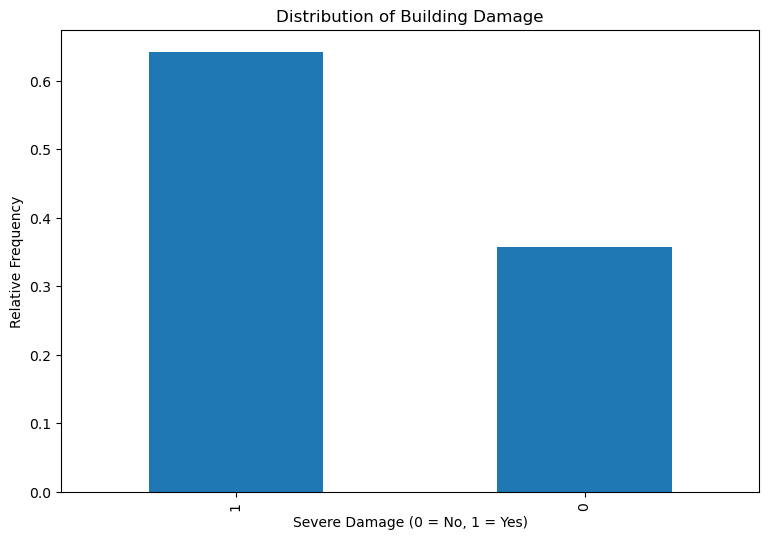

Class distribution:
severe_damage
1    0.642597
0    0.357403
Name: proportion, dtype: float64


In [17]:
# Calculate class distribution
class_distribution = df['severe_damage'].value_counts("class_dist")

# Create bar plot
fig, ax = plt.subplots(figsize=(9, 6))
class_distribution.plot(kind='bar', ax=ax)
ax.set_xlabel("Severe Damage (0 = No, 1 = Yes)")
ax.set_ylabel("Relative Frequency")
ax.set_title("Distribution of Building Damage")
plt.show()

print(f"Class distribution:\n{class_distribution}")

In [18]:
# Get categorical columns and their unique value counts
cat_unique_counts = df.select_dtypes('object').nunique()   

print("Categorical feature unique value counts:")
print(cat_unique_counts)

Categorical feature unique value counts:
foundation_type      5
ground_floor_type    5
dtype: int64


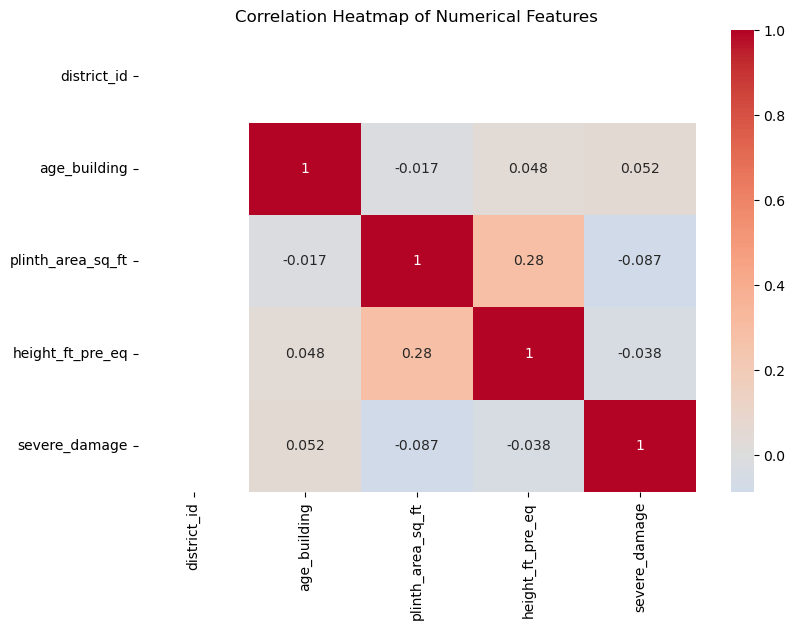

Correlation matrix created!
                   district_id  age_building  plinth_area_sq_ft  \
district_id                NaN           NaN                NaN   
age_building               NaN      1.000000          -0.016856   
plinth_area_sq_ft          NaN     -0.016856           1.000000   
height_ft_pre_eq           NaN      0.047652           0.283496   
severe_damage              NaN      0.051580          -0.086714   

                   height_ft_pre_eq  severe_damage  
district_id                     NaN            NaN  
age_building               0.047652       0.051580  
plinth_area_sq_ft          0.283496      -0.086714  
height_ft_pre_eq           1.000000      -0.038477  
severe_damage             -0.038477       1.000000  


In [19]:
import seaborn as sns

# Create correlation matrix for numerical features
correlation = df.select_dtypes('number').corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features')
plt.show()

print("Correlation matrix created!")
print(correlation)

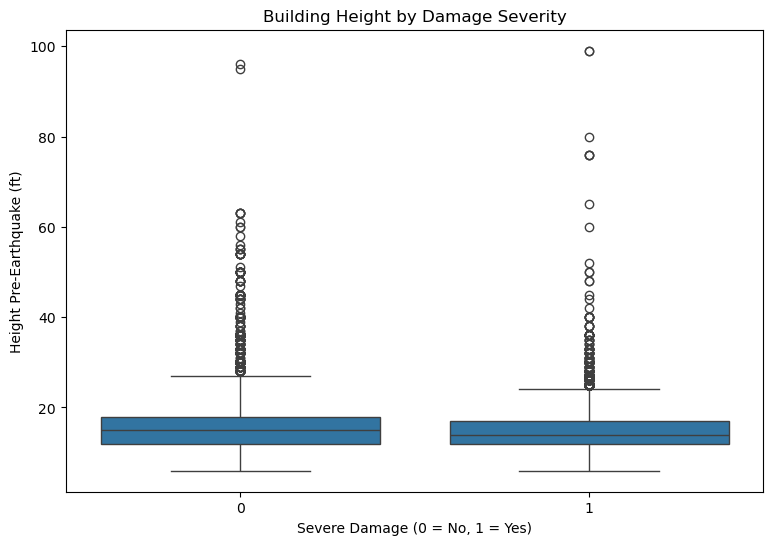

Boxplot created!


In [20]:
# Create boxplot
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(x='severe_damage', y='height_ft_pre_eq', data=df, ax=ax)
ax.set_xlabel('Severe Damage (0 = No, 1 = Yes)')
ax.set_ylabel('Height Pre-Earthquake (ft)')
ax.set_title('Building Height by Damage Severity')
plt.show()

print("Boxplot created!")

Severe damage rate by foundation type:
                        severe_damage
foundation_type                      
RC                           0.026224
Bamboo/Timber                0.324074
Cement-Stone/Brick           0.421908
Mud mortar-Stone/Brick       0.687792
Other                        0.818898


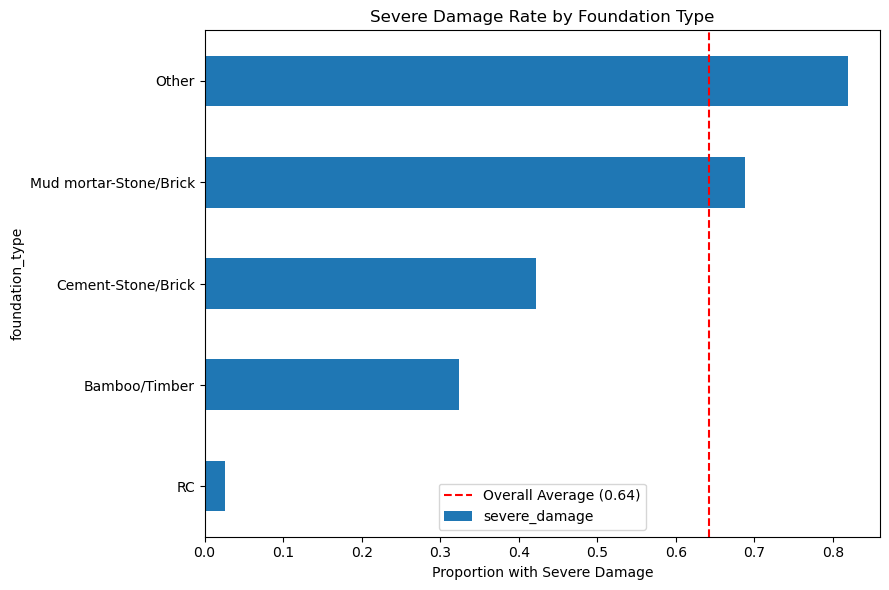

In [21]:
# Create pivot table
foundation_damage = pd.pivot_table(
    df, values='severe_damage',
    index='foundation_type',
    aggfunc='mean'
).sort_values('severe_damage')

print("Severe damage rate by foundation type:")
print(foundation_damage)

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 6))
foundation_damage.plot(kind='barh', ax=ax, legend=False)
ax.set_xlabel('Proportion with Severe Damage')
ax.set_title('Severe Damage Rate by Foundation Type')
ax.axvline(x=df['severe_damage'].mean(), color='red', linestyle='--',
           label=f'Overall Average ({df["severe_damage"].mean():.2f})')
ax.legend()
plt.tight_layout()
plt.show()


---
### Data Encoding and Logistic Regression


In [22]:
# Define target variable
target = 'severe_damage'

# Get all columns except target using list comprehension
features = [col for col in df.columns if col != target]

print(f"Target: {target}")
print(f"Number of features: {len(features)}")
print(f"Features: {features}")

Target: severe_damage
Number of features: 6
Features: ['district_id', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq', 'foundation_type', 'ground_floor_type']


In [23]:
# Create feature matrix and target vector
X = df[features]
y = df[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFirst 5 rows of X:")
print(X.head())
print(f"\nFirst 5 values of y:")
print(y.head())

X shape: (70836, 6)
y shape: (70836,)

First 5 rows of X:
             district_id  age_building  plinth_area_sq_ft  height_ft_pre_eq  \
building_id                                                                   
196883                 4             3                225                14   
196912                 4             7                346                15   
197006                 4            15                405                16   
197017                 4            11                340                10   
197045                 4            15                324                15   

            foundation_type ground_floor_type  
building_id                                    
196883                Other       Brick/Stone  
196912                Other       Brick/Stone  
197006                Other       Brick/Stone  
197017                Other               Mud  
197045                Other       Brick/Stone  

First 5 values of y:
building_id
196883    1
196912

In [24]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test set: X_test {X_test.shape}, y_test {y_test.shape}")

Training set: X_train (56668, 6), y_train (56668,)
Test set: X_test (14168, 6), y_test (14168,)


In [25]:
# Calculate baseline accuracy (predict majority class)
baseline_acc = y_train.value_counts(normalize=True).max()  

print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"This means predicting '{y_train.value_counts().idxmax()}' for all buildings gives {baseline_acc:.2%} accuracy")

Baseline Accuracy: 0.6423
This means predicting '1' for all buildings gives 64.23% accuracy


In [26]:
from sklearn.pipeline import Pipeline

# Create pipeline with OneHotEncoder and LogisticRegression
model = Pipeline([
    ('encoder', OneHotEncoder(use_cat_names = True)),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Fit the model
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"\nModel steps: {model.steps}")

Model trained successfully!

Model steps: [('encoder', OneHotEncoder(cols=['foundation_type', 'ground_floor_type'], use_cat_names=True)), ('classifier', LogisticRegression(max_iter=1000))]


In [27]:
# Calculate accuracy scores
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"\nImprovement over baseline: {test_acc - baseline_acc:.4f}")

Training Accuracy: 0.7037
Test Accuracy: 0.7063
Baseline Accuracy: 0.6423

Improvement over baseline: 0.0640


In [28]:
# Calculate precision and recall
y_pred = model.predict(X_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nInterpretation:")
print(f"- Precision: When model predicts severe damage, it is correct {precision:.2%} of the time")
print(f"- Recall: Model identifies {recall:.2%} of all severely damaged buildings")

Precision: 0.6965
Recall: 0.9638

Interpretation:
- Precision: When model predicts severe damage, it is correct 69.65% of the time
- Recall: Model identifies 96.38% of all severely damaged buildings


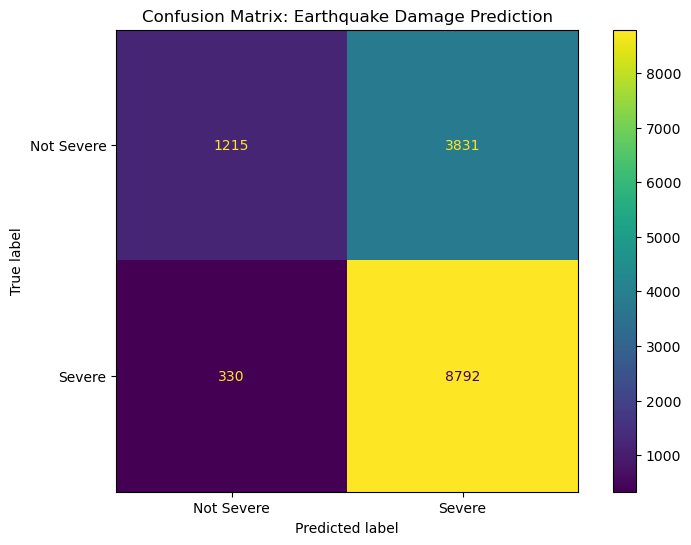

Confusion Matrix:
[[1215 3831]
 [ 330 8792]]


In [29]:
# Create confusion matrix
cm = confusion_matrix(y_test, model.predict(X_test))

# Display confusion matrix
fig, ax = plt.subplots(figsize=(9, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Severe', 'Severe'])
disp.plot(ax=ax)
ax.set_title('Confusion Matrix: Earthquake Damage Prediction')
plt.show()

print("Confusion Matrix:")
print(cm)

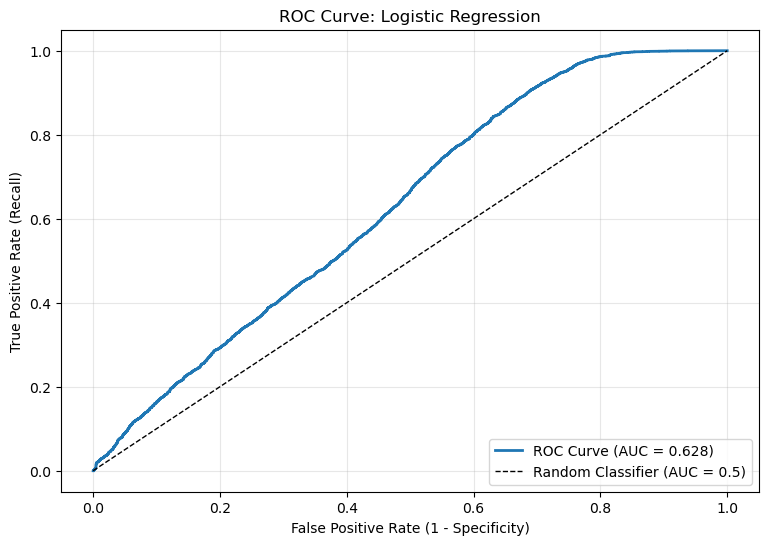

AUC Score: 0.6280

Interpretation:
- AUC = 0.5: Random guessing
- AUC = 1.0: Perfect classifier
- AUC = 0.628: Our model's performance


In [30]:
# Get predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', linewidth=1)
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve: Logistic Regression')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()

print(f"AUC Score: {auc_score:.4f}")
print(f"\nInterpretation:")
print(f"- AUC = 0.5: Random guessing")
print(f"- AUC = 1.0: Perfect classifier")
print(f"- AUC = {auc_score:.3f}: Our model's performance")

In [31]:
# Extract feature names and coefficients
feature_names = model.named_steps['encoder'].get_feature_names_out()
coefficients = model.named_steps['classifier'].coef_[0]

# Calculate odds ratios
odds_ratios = pd.Series(np.exp(coefficients), index=feature_names).sort_values()

print("Top 5 features that DECREASE odds of severe damage:")
print(odds_ratios.head())
print("\nTop 5 features that INCREASE odds of severe damage:")
print(odds_ratios.tail())

Top 5 features that DECREASE odds of severe damage:
foundation_type_RC               0.086493
ground_floor_type_RC             0.342668
foundation_type_Bamboo/Timber    0.627157
ground_floor_type_Other          0.798215
district_id                      0.854655
dtype: float64

Top 5 features that INCREASE odds of severe damage:
foundation_type_Cement-Stone/Brick        1.253127
ground_floor_type_Brick/Stone             1.463735
ground_floor_type_Timber                  2.038837
foundation_type_Mud mortar-Stone/Brick    2.777960
foundation_type_Other                     5.091756
dtype: float64


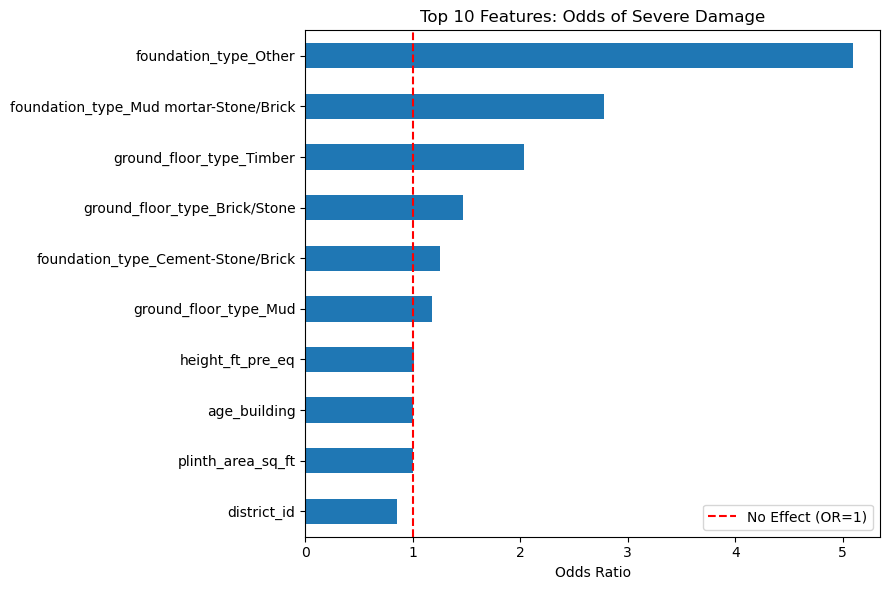

In [32]:
# Plot top 10 odds ratios
fig, ax = plt.subplots(figsize=(9, 6))
odds_ratios.tail(10).plot(kind='barh', ax=ax)
ax.set_xlabel('Odds Ratio')
ax.set_title('Top 10 Features: Odds of Severe Damage')
ax.axvline(x=1, color='red', linestyle='--', label='No Effect (OR=1)')
ax.legend()
plt.tight_layout()
plt.show()

---
### Decision Trees modelling

In [33]:
# Load Gorkha district data (district_id = 4) from the `data` folder
df = wrangle_nepal_data('C:/Users/HomePC/Downloads/Nepal data modelling/Nepal_data', district_id=4)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nSevere damage rate: {df['severe_damage'].mean():.2%}")

Dataset shape: (70836, 7)
Columns: ['district_id', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq', 'foundation_type', 'ground_floor_type', 'severe_damage']

Severe damage rate: 64.26%


In [34]:
# Define target and features
target = 'severe_damage'
features = [col for col in df.columns if col != target]

# Create X and y
X = df[features]   
y = df[target]   

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {features}")

X shape: (70836, 6)
y shape: (70836,)
Features: ['district_id', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq', 'foundation_type', 'ground_floor_type']


In [35]:
# First split: separate test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Second split: separate validation from training (25% of 80% = 20% overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X):.1%})")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.1%})")

Training set: 42501 samples (60.0%)
Validation set: 14167 samples (20.0%)
Test set: 14168 samples (20.0%)


In [36]:
# Calculate baseline (predict majority class)
baseline_acc = y_train.value_counts(normalize=True).max()

print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"Majority class: {y_train.value_counts().idxmax()}")

Baseline Accuracy: 0.6427
Majority class: 1


In [37]:
# Create pipeline
model = Pipeline([
    ('encoder', OrdinalEncoder()),
    ('tree', DecisionTreeClassifier(max_depth=6, random_state=42))
])

# Fit the model
model.fit(X_train, y_train)

# Calculate accuracies
train_acc = accuracy_score(y_train, model.predict(X_train))
val_acc = accuracy_score(y_val, model.predict(X_val))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Baseline Accuracy: {baseline_acc:.4f}")

Training Accuracy: 0.7127
Validation Accuracy: 0.7063
Baseline Accuracy: 0.6427


In [38]:
# Test different max_depth values
depths = range(1, 16)
train_accuracies = []
val_accuracies = []

for depth in depths:   
    # Create and train model
    model = Pipeline([
        ('encoder', OrdinalEncoder()),
        ('tree', DecisionTreeClassifier(max_depth=depth, random_state=42)) 
    ])
    model.fit(X_train, y_train)

    # Calculate accuracies
    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

print("Hyperparameter tuning complete!")
print(f"Best validation accuracy: {max(val_accuracies):.4f} at depth {list(depths)[val_accuracies.index(max(val_accuracies))]}")

Hyperparameter tuning complete!
Best validation accuracy: 0.7080 at depth 7


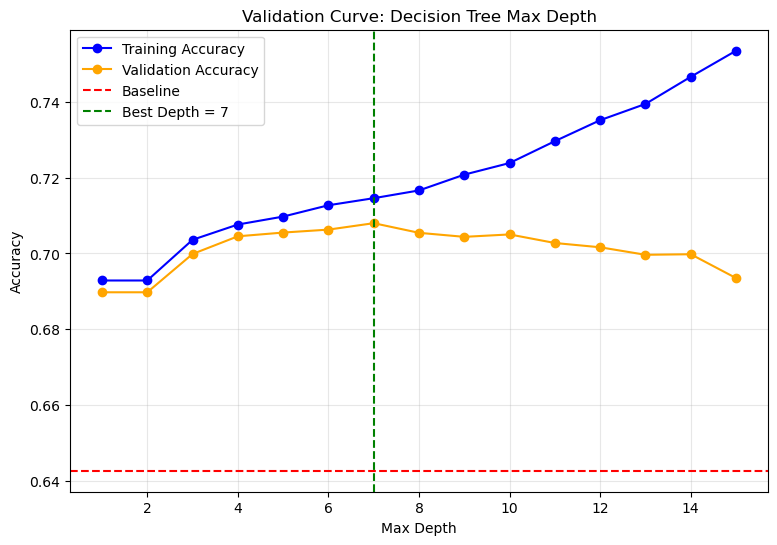

In [39]:
# Find the depth with the best validation accuracy
best_depth = list(depths)[val_accuracies.index(max(val_accuracies))]

# Plot validation curve
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(depths, train_accuracies, 'o-', label='Training Accuracy', color='blue')
ax.plot(depths, val_accuracies, 'o-', label='Validation Accuracy', color='orange')
ax.axhline(y=baseline_acc, color='red', linestyle='--', label='Baseline')
ax.axvline(x=best_depth, color='green', linestyle='--', label=f'Best Depth = {best_depth}')
ax.set_xlabel('Max Depth')
ax.set_ylabel('Accuracy')
ax.set_title('Validation Curve: Decision Tree Max Depth')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [40]:
# Train final model with best hyperparameter
final_model = Pipeline([
    ('encoder', OrdinalEncoder()),
    ('tree', DecisionTreeClassifier(max_depth=6, random_state=42))
])
final_model.fit(X_train, y_train)

# Evaluate on test set
test_acc = accuracy_score(y_test, final_model.predict(X_test))

print(f"\nFinal Model Performance:")
print(f"Training Accuracy: {accuracy_score(y_train, final_model.predict(X_train)):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, final_model.predict(X_val)):.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Baseline Accuracy: {baseline_acc:.4f}")


Final Model Performance:
Training Accuracy: 0.7127
Validation Accuracy: 0.7063
Test Accuracy: 0.7182
Baseline Accuracy: 0.6427


Top 10 Most Important Features:
foundation_type      0.694906
ground_floor_type    0.106031
height_ft_pre_eq     0.101547
age_building         0.072192
plinth_area_sq_ft    0.025324
district_id          0.000000
dtype: float64


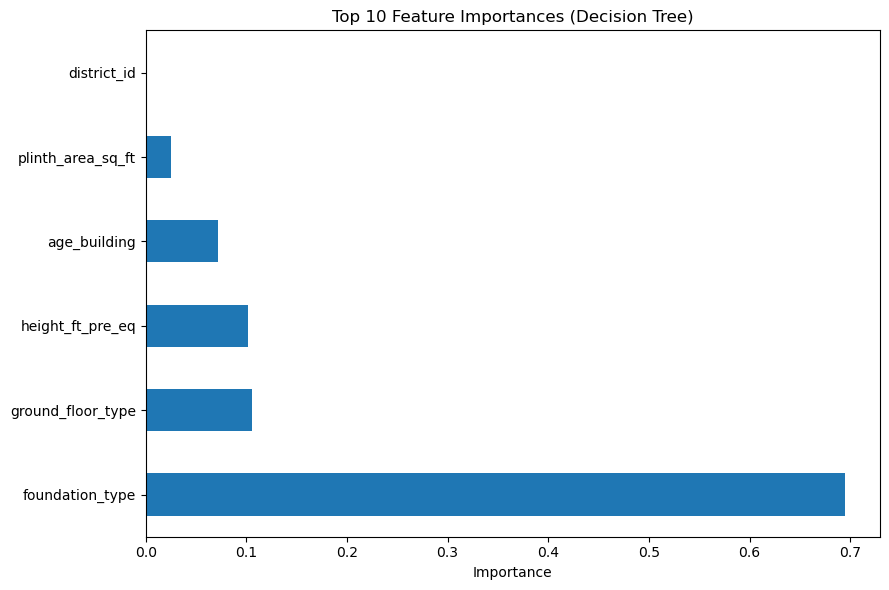

In [41]:
# Get feature importances
importances = final_model.named_steps['tree'].feature_importances_
feature_names = final_model.named_steps['encoder'].get_feature_names_out()

# Create Series and sort
feature_importance = pd.Series(importances, index= feature_names ).sort_values(ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
feature_importance.head(10).plot(kind='barh', ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Top 10 Feature Importances (Decision Tree)')
plt.tight_layout()
plt.show()

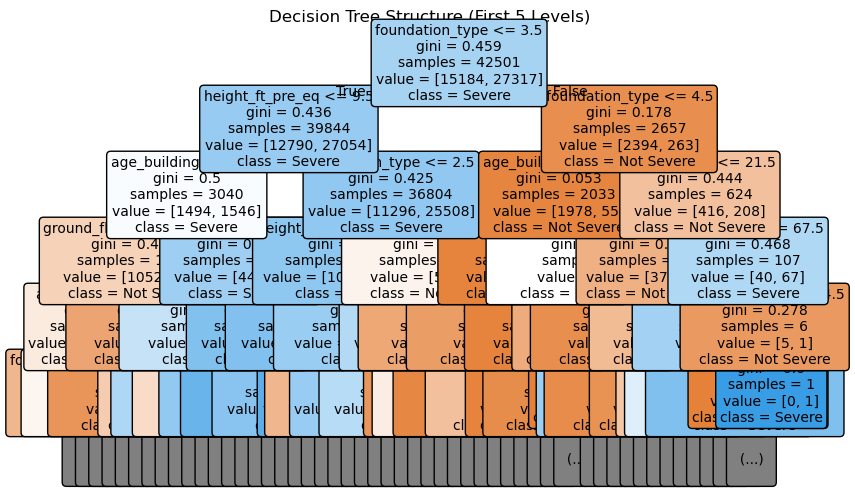

In [42]:
# Visualize the tree (first 2 levels)
fig, ax = plt.subplots(figsize=(9, 6))
plot_tree(
    final_model.named_steps['tree'],
    feature_names=feature_names,
    class_names=['Not Severe', 'Severe'],
    filled=True,
    rounded=True,
    max_depth=5,
    ax=ax,
    fontsize=10
)
ax.set_title('Decision Tree Structure (First 5 Levels)')
plt.show()

In [43]:
logistic_regression_accuracy = 0.706  # From Lesson 2

print("Model Comparison:")
print("=" * 50)
print(f"{'Model':<25} {'Test Accuracy':<15}")
print("=" * 50)
print(f"{'Baseline':<25} {baseline_acc:<15.4f}")
print(f"{'Logistic Regression':<25} {logistic_regression_accuracy:<15.4f}")
print(f"{'Decision Tree':<25} {test_acc:<15.4f}")
print("=" * 50)

# Calculate improvements
print(f"\nImprovement over baseline:")
print(f"  Logistic Regression: +{logistic_regression_accuracy - baseline_acc:.4f}")
print(f"  Decision Tree: +{test_acc - baseline_acc:.4f}")

if test_acc > logistic_regression_accuracy:
    print(f"\n✓ Decision Tree wins by {test_acc - logistic_regression_accuracy:.4f}")
else:
    print(f"\n✗ Logistic Regression wins by {logistic_regression_accuracy - test_acc:.4f}")

Model Comparison:
Model                     Test Accuracy  
Baseline                  0.6427         
Logistic Regression       0.7060         
Decision Tree             0.7182         

Improvement over baseline:
  Logistic Regression: +0.0633
  Decision Tree: +0.0754

✓ Decision Tree wins by 0.0122


---
### IDENTIFYING THE DEMOGRAPHIC THAT WOULD BE AFFECTED THE MOST BY AN EARTHQUAKE 

In [44]:
# Connect to database
conn = duckdb.connect('./nepal.sqlite')

# Query household_demographics table
df_demo = conn.execute("""
    SELECT *
    FROM household_demographics
    LIMIT 5
""").df()

conn.close()

print(f"Shape: {df_demo.shape}")
print("\nColumns:", df_demo.columns.tolist())
print("\nFirst 5 rows:")
print(df_demo)

Shape: (5, 8)

Columns: ['household_id', 'gender_household_head', 'age_household_head', 'caste_household', 'education_level_household_head', 'income_level_household', 'size_household', 'is_bank_account_present_in_household']

First 5 rows:
   household_id gender_household_head  age_household_head caste_household  \
0           101                  Male                31.0             Rai   
1           201                Female                62.0             Rai   
2           301                  Male                51.0   Gharti/Bhujel   
3           401                  Male                48.0   Gharti/Bhujel   
4           501                  Male                70.0   Gharti/Bhujel   

  education_level_household_head income_level_household  size_household  \
0                     Illiterate        Rs. 10 thousand             3.0   
1                     Illiterate        Rs. 10 thousand             6.0   
2                     Illiterate        Rs. 10 thousand            13.0 

In [45]:
conn = duckdb.connect('./nepal.sqlite')

count_df = conn.execute("""
    SELECT COUNT(*) as count
    FROM household_demographics
""").df()

conn.close()

demo_count = count_df.loc[0, 'count']
print(f"Number of households: {demo_count}")

Number of households: 249932


In [46]:
district_id = 4

conn = duckdb.connect('./nepal.sqlite')

query = f"""
    SELECT
        h.*,
        s.*,
        i.vdcmun_id,
        d.damage_grade
    FROM household_demographics h
    JOIN id_map i ON h.household_id = i.household_id
    JOIN building_structure s ON i.building_id = s.building_id
    JOIN building_damage d ON i.building_id = d.building_id
    WHERE i.district_id = {district_id}
    LIMIT 10
""" 

df_joined = conn.execute(query).df()
conn.close()

print(f"Shape: {df_joined.shape}")
print(f"\nColumns: {df_joined.columns.tolist()}")
print("\nFirst few rows:")
print(df_joined.head())

Shape: (10, 26)

Columns: ['household_id', 'gender_household_head', 'age_household_head', 'caste_household', 'education_level_household_head', 'income_level_household', 'size_household', 'is_bank_account_present_in_household', 'building_id', 'count_floors_pre_eq', 'count_floors_post_eq', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq', 'height_ft_post_eq', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'condition_post_eq', 'superstructure', 'vdcmun_id', 'damage_grade']

First few rows:
   household_id gender_household_head  age_household_head caste_household  \
0      16403001                  Male                35.0        Chhetree   
1      16403101                Female                50.0    Brahman-Hill   
2      16403201                  Male                42.0          Gurung   
3      16403301                  Male                37.0        Chhetree   
4      16403401               

In [47]:
conn = duckdb.connect('./nepal.sqlite')

query = """
    SELECT
        h.*,
        s.*,
        i.vdcmun_id,
        d.damage_grade
    FROM household_demographics h
    JOIN id_map i ON h.household_id = i.household_id
    JOIN building_structure s ON i.building_id = s.building_id
    JOIN building_damage d ON i.building_id = d.building_id
    WHERE i.district_id = 4
"""

# Load data
df = conn.execute(query).df()
conn.close()

# Create binary target, set index, and drop leaky columns
cols_to_drop = [col for col in df.columns if 'post_eq' in col] + \
               ['building_id', 'damage_grade', 'count_floors_pre_eq']

df = (df
  .assign(severe_damage=df['damage_grade']           # <--- Create binary target column
    .str.contains('Grade 4|Grade 5')                 # <--- Check if grade contains 4 or 5
    .astype(int))                                    # <--- Convert to 0/1 integer
  .set_index('household_id')                         # <--- Use household_id as row index
  .drop(columns=cols_to_drop))                       # <--- Remove post-earthquake and other leaky columns

print(f"Final shape: {df.shape}")
print(f"Severe damage rate: {df['severe_damage'].mean():.2%}")

Final shape: (75883, 20)
Severe damage rate: 63.10%


In [48]:
# Check unique values in categorical columns
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns       
cardinality = df[cat_cols].nunique().sort_values(ascending=False)    

print("Categorical feature cardinality:")
print(cardinality)
print(f"\nTop 10 most common castes:")
print(df['caste_household'].value_counts().head(10))

Categorical feature cardinality:
caste_household                   63
education_level_household_head    19
superstructure                    11
plan_configuration                10
income_level_household             5
foundation_type                    5
ground_floor_type                  5
other_floor_type                   4
position                           4
land_surface_condition             3
roof_type                          3
gender_household_head              2
dtype: int64

Top 10 most common castes:
caste_household
Gurung          15119
Brahman-Hill    13043
Chhetree         8766
Magar            8180
Sarki            6052
Newar            5906
Kami             3565
Tamang           2396
Kumal            2271
Damai/Dholi      1977
Name: count, dtype: int64


In [49]:
# Get top 10 castes
top_10_castes = (df['caste_household']
  .value_counts()                   # <--- Count frequency of each caste
  .head(10)                         # <--- Keep only top 10 most common
  .index)                           # <--- Extract caste names

# Group rare castes as "Other"
df = (df
  .assign(caste_household=df['caste_household'].apply(
      lambda c: c if c in top_10_castes else 'Other'  # <--- Keep top 10 castes, group rest as "Other"
  )))

print(f"Unique castes after grouping: {df['caste_household'].nunique()}")
print("\nCaste distribution:")
print(df['caste_household'].value_counts())

Unique castes after grouping: 11

Caste distribution:
caste_household
Gurung          15119
Brahman-Hill    13043
Chhetree         8766
Other            8608
Magar            8180
Sarki            6052
Newar            5906
Kami             3565
Tamang           2396
Kumal            2271
Damai/Dholi      1977
Name: count, dtype: int64


In [50]:
# Define target and features
target = 'severe_damage'
features = [col for col in df.columns if col != target]

# Create X and y
X = df[features]   # <-- feature matrix
y = df[target]   # <-- target vector

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures include: {features[:5]}...")

X shape: (75883, 19)
y shape: (75883,)

Features include: ['gender_household_head', 'age_household_head', 'caste_household', 'education_level_household_head', 'income_level_household']...


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Training: 60706 samples
Test: 15177 samples


In [52]:
baseline_acc = y_train.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {baseline_acc:.4f}")

Baseline Accuracy: 0.6296


In [53]:
# Build model
model = Pipeline([
    ('encoder', OneHotEncoder(use_cat_names=True)),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Fit model
model.fit(X_train, y_train)

# Evaluate
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Baseline Accuracy: {baseline_acc:.4f}")


C:\Users\HomePC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Accuracy: 0.7263
Test Accuracy: 0.7314
Baseline Accuracy: 0.6296


Top 10 features INCREASING odds of severe damage:
other_floor_type_Timber-Planck            2.092398
foundation_type_Mud mortar-Stone/Brick    2.217301
plan_configuration_Square                 2.229103
superstructure_Adobe/mud                  2.252023
gender_household_head_Male                2.255375
roof_type_Bamboo/Timber-Heavy roof        2.264449
superstructure_Stone, mud mortar          2.529727
foundation_type_Other                     2.555046
roof_type_Bamboo/Timber-Light roof        2.683184
superstructure_Stone                      3.587324
dtype: float64


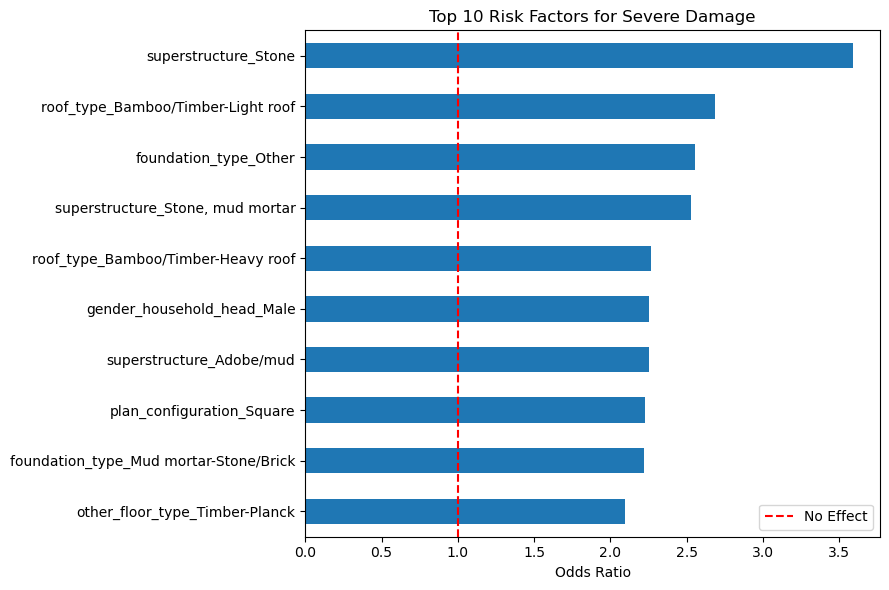

In [54]:
# Get feature names and coefficients
feature_names = model.named_steps['encoder'].get_feature_names_out()
coefficients = model.named_steps['classifier'].coef_[0]

# Create odds ratios
odds_ratios = pd.Series(np.exp(coefficients), index=feature_names).sort_values()

print("Top 10 features INCREASING odds of severe damage:")
print(odds_ratios.tail(10))

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
odds_ratios.tail(10).plot(kind='barh', ax=ax)
ax.set_xlabel('Odds Ratio')
ax.set_title('Top 10 Risk Factors for Severe Damage')
ax.axvline(x=1, color='red', linestyle='--', label='No Effect')
ax.legend()
plt.tight_layout()
plt.show()

Top 10 municipalities by damage rate:
           damage_rate  count
vdcmun_id                    
31            0.930199   4169
32            0.851117   7160
35            0.827145   3905
30            0.824201   6917
33            0.782464   6615
34            0.666979   2132
39            0.572344   7492
40            0.512444   6951
38            0.506425  11362
36            0.503972   5790


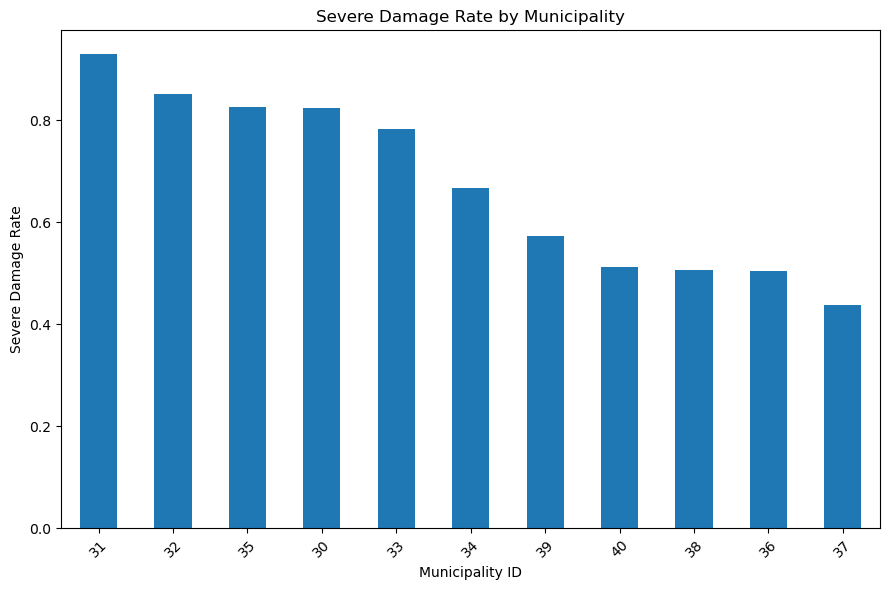

In [55]:
# Damage by municipality
damage_by_municipality = df.groupby('vdcmun_id')['severe_damage'].agg(['mean', 'count'])
damage_by_municipality.columns = ['damage_rate', 'count']
damage_by_municipality = damage_by_municipality.sort_values('damage_rate', ascending=False)

print("Top 10 municipalities by damage rate:")
print(damage_by_municipality.head(10))

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
damage_by_municipality['damage_rate'].head(15).plot(kind='bar', ax=ax)
ax.set_xlabel('Municipality ID')
ax.set_ylabel('Severe Damage Rate')
ax.set_title('Severe Damage Rate by Municipality')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Top 10 features DECREASING odds of severe damage (protective factors):
superstructure_Brick, cement mortar    0.525300
foundation_type_RC                     0.573470
roof_type_RCC/RB/RBC                   0.752334
caste_household_Kumal                  0.761506
superstructure_RC, non-engineered      0.762473
superstructure_Other                   0.770113
superstructure_Bamboo                  0.798035
superstructure_Timber                  0.807769
vdcmun_id                              0.812385
foundation_type_Bamboo/Timber          0.849471
dtype: float64


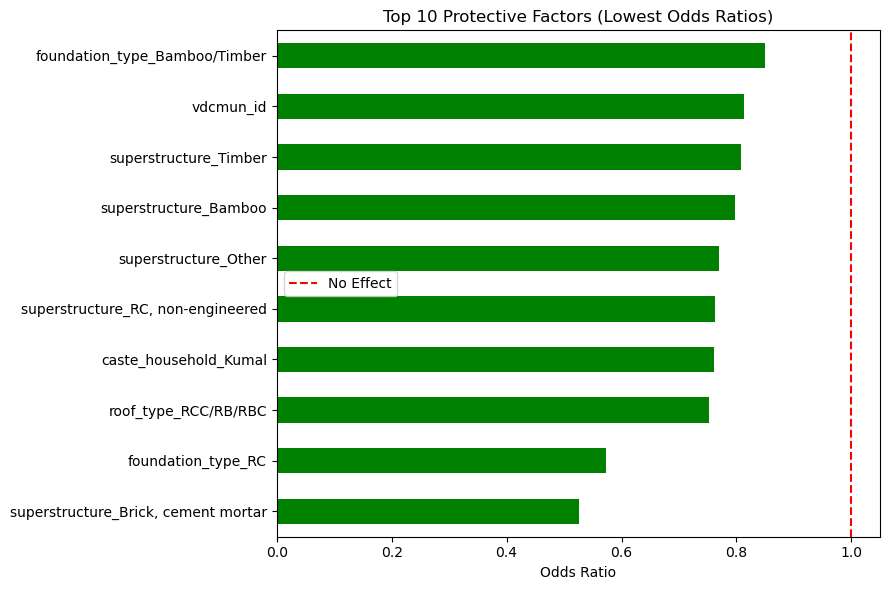

In [56]:
print("Top 10 features DECREASING odds of severe damage (protective factors):")
print(odds_ratios.head(10))

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
odds_ratios.head(10).plot(kind='barh', ax=ax, color='green')
ax.set_xlabel('Odds Ratio')
ax.set_title('Top 10 Protective Factors (Lowest Odds Ratios)')
ax.axvline(x=1, color='red', linestyle='--', label='No Effect')
ax.legend()
plt.tight_layout()
plt.show()

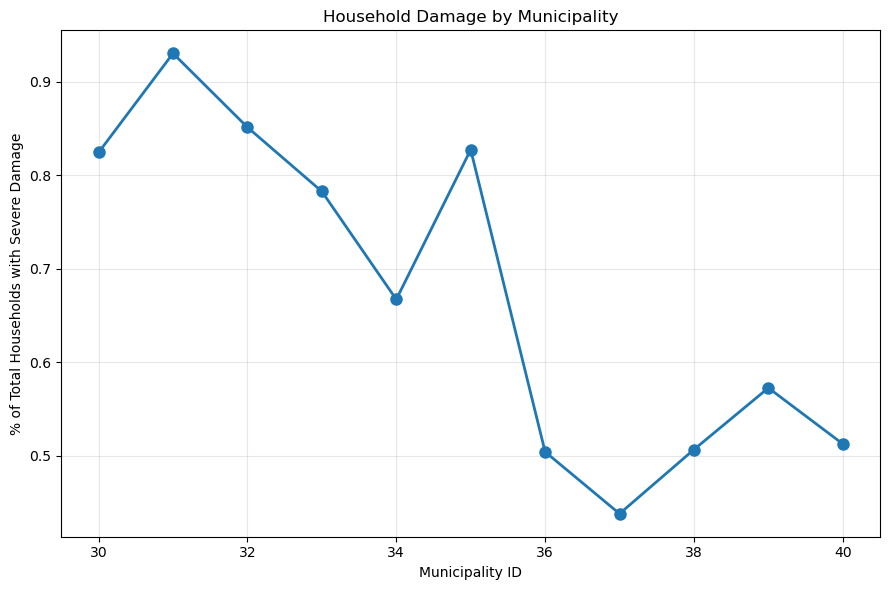

In [57]:
# Sort by municipality ID for line plot
damage_by_municipality_sorted = damage_by_municipality.sort_index()

# Create line plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(damage_by_municipality_sorted.index,
        damage_by_municipality_sorted['damage_rate'],
        marker='o', linewidth=2, markersize=8)
ax.set_xlabel('Municipality ID')
ax.set_ylabel('% of Total Households with Severe Damage')
ax.set_title('Household Damage by Municipality')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
# Calculate proportion of Gurung households by municipality
gurung_by_municipality = (
    df[df['caste_household'] == 'Gurung']
    .groupby('vdcmun_id')
    .size()
)

# Total households by municipality
total_by_municipality = df.groupby('vdcmun_id').size()

# Calculate proportion
damage_by_municipality['gurung_pct'] = (
    gurung_by_municipality / total_by_municipality
).fillna(0)

print("Gurung population by municipality:")
print(damage_by_municipality[['damage_rate', 'gurung_pct']].sort_values('gurung_pct', ascending=False))

Gurung population by municipality:
           damage_rate  gurung_pct
vdcmun_id                         
35            0.827145    0.826889
32            0.851117    0.387849
34            0.666979    0.385084
30            0.824201    0.338152
31            0.930199    0.326937
40            0.512444    0.246727
36            0.503972    0.143178
39            0.572344    0.097971
37            0.437789    0.050485
38            0.506425    0.049023
33            0.782464    0.011943


In [59]:
# Calculate proportion of Kumal households by municipality
kumal_by_municipality = (
    df[df['caste_household'] == 'Kumal']
    .groupby('vdcmun_id')
    .size()
)

# Calculate proportion (NaN will become 0)
damage_by_municipality['kumal_pct'] = (
    kumal_by_municipality / total_by_municipality
).fillna(0)

print("Kumal population by municipality:")
print(damage_by_municipality[['damage_rate', 'kumal_pct']].sort_values('kumal_pct', ascending=False))

# Show correlation
print(f"\nCorrelation between damage rate and Gurung population: {damage_by_municipality['damage_rate'].corr(damage_by_municipality['gurung_pct']):.3f}")
print(f"Correlation between damage rate and Kumal population: {damage_by_municipality['damage_rate'].corr(damage_by_municipality['kumal_pct']):.3f}")

Kumal population by municipality:
           damage_rate  kumal_pct
vdcmun_id                        
38            0.506425   0.100686
37            0.437789   0.048842
40            0.512444   0.036973
33            0.782464   0.029478
36            0.503972   0.003282
39            0.572344   0.000267
31            0.930199   0.000000
32            0.851117   0.000000
35            0.827145   0.000000
30            0.824201   0.000000
34            0.666979   0.000000

Correlation between damage rate and Gurung population: 0.570
Correlation between damage rate and Kumal population: -0.566


---
### Predicting Earthquake Damage for Kavrepalanchok district  with Classification Models

In [61]:
# Count buildings per district using DuckDB
district_counts = duckdb.sql("""
    SELECT district_id, COUNT(DISTINCT building_id) as building_count
    FROM 'C:/Users/HomePC/Downloads/Nepal data modelling/Nepal_data/id_map.csv'
    GROUP BY district_id
    ORDER BY district_id
""").fetchdf()

print("Building count by district:")
print(district_counts)

Building count by district:
   district_id  building_count
0            1           35285
1            2           52181
2            3           76533
3            4           70836


In [62]:
district_id_assign = 3  

print(f"Kavrepalanchok district ID: {district_id_assign}")

Kavrepalanchok district ID: 3


In [63]:
# Connect to database
conn = duckdb.connect('./nepal.sqlite')

# Write your SQL query here 
query = f"""
    SELECT
        s.*,
        d.damage_grade
    FROM building_structure s
    JOIN building_damage d ON s.building_id = d.building_id
    JOIN id_map i ON s.building_id = i.building_id
    WHERE i.district_id = {district_id_assign}
"""

# Execute query and load into DataFrame
df_assignment_final = conn.execute(query).df()
conn.close()

# Create binary target variable
df_assignment_final = (df_assignment_final
  .assign(severe_damage=df_assignment_final['damage_grade']        
    .str.contains('Grade 4|Grade 5')                              
    .astype(int)))                                                

# Drop leaky columns
cols_to_drop = [col for col in df_assignment_final.columns if 'post_eq' in col] + \
               ['building_id', 'damage_grade', 'count_floors_pre_eq']
df_assignment_final = df_assignment_final.drop(columns=cols_to_drop)

print(f"Shape: {df_assignment_final.shape}")
print(df_assignment_final.head())

Shape: (82684, 12)
   age_building  plinth_area_sq_ft  height_ft_pre_eq land_surface_condition  \
0            40                324                12                   Flat   
1            30                382                20                   Flat   
2            13                405                10                   Flat   
3            25                328                18                   Flat   
4            15                405                20                   Flat   

          foundation_type                 roof_type ground_floor_type  \
0  Mud mortar-Stone/Brick  Bamboo/Timber-Light roof               Mud   
1  Mud mortar-Stone/Brick  Bamboo/Timber-Light roof               Mud   
2  Mud mortar-Stone/Brick  Bamboo/Timber-Light roof               Mud   
3  Mud mortar-Stone/Brick  Bamboo/Timber-Heavy roof               Mud   
4  Mud mortar-Stone/Brick  Bamboo/Timber-Light roof               Mud   

    other_floor_type         position plan_configuration     supers

In [64]:
# Count severe damage cases
severe_damage_count = df_assignment_final['severe_damage'].sum() 

print(f"Severe damage cases: {severe_damage_count}")
print(f"Total cases: {len(df_assignment_final)}")
print(f"Percentage: {severe_damage_count / len(df_assignment_final) * 100:.1f}%")

Severe damage cases: 45196
Total cases: 82684
Percentage: 54.7%


In [65]:
X_assign_final = df_assignment_final.drop(columns=['severe_damage'])   
y_assign_final = df_assignment_final['severe_damage']                   

X_train_assign, X_test_assign, y_train_assign, y_test_assign = train_test_split(
    X_assign_final, y_assign_final, test_size=0.2, random_state=42              
)

In [66]:
encoder_final = OneHotEncoder(use_cat_names=True)
X_train_assign_enc = encoder_final.fit_transform(X_train_assign)  
X_test_assign_enc = encoder_final.transform(X_test_assign)       

In [67]:
assignment_tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)   
assignment_tree_model.fit(X_train_assign_enc, y_train_assign)                                             

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [68]:
y_pred_assign = assignment_tree_model.predict(X_test_assign_enc)       

final_score_acc = accuracy_score(y_test_assign, y_pred_assign)              
final_score_prec = precision_score(y_test_assign, y_pred_assign)             
final_score_rec = recall_score(y_test_assign, y_pred_assign)                 

print(f"Final Accuracy: {final_score_acc:.4f}")
print(f"Final Precision: {final_score_prec:.4f}")
print(f"Final Recall Score: {final_score_rec:.4f}")

Final Accuracy: 0.6659
Final Precision: 0.6378
Final Recall Score: 0.9010


In [69]:
importances_assign = assignment_tree_model.feature_importances_
feat_names_assign = X_train_assign_enc.columns
feat_imp_assign_series = pd.Series(importances_assign, index=feat_names_assign)            

most_important_feature_name = feat_imp_assign_series.idxmax()
print(f"Most important feature: {most_important_feature_name}")

Most important feature: roof_type_RCC/RB/RBC


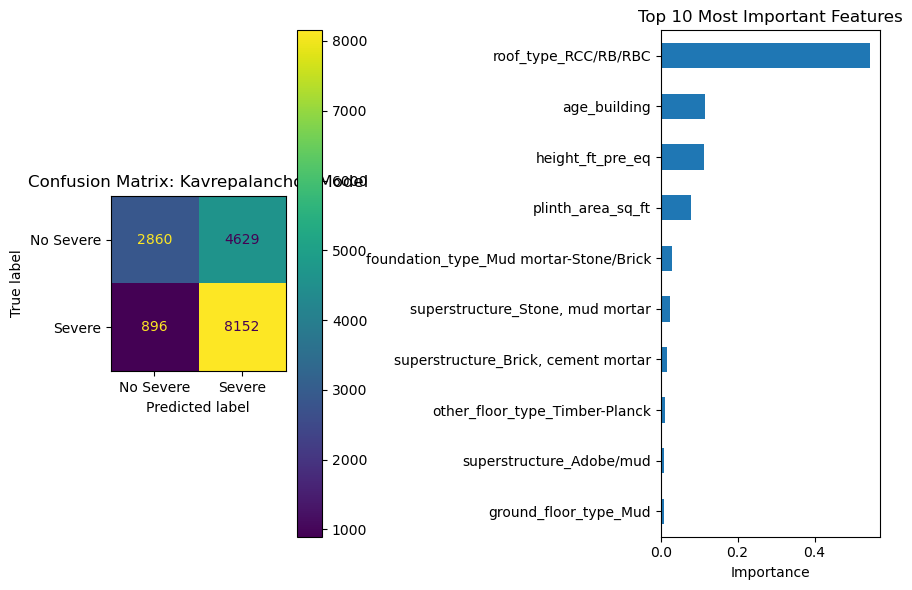


Model Summary for Kavrepalanchok:
- Total buildings: 82684
- Severe damage rate: 54.7%
- Test accuracy: 0.666
- Most important feature: roof_type_RCC/RB/RBC


In [70]:
# Create subplots for confusion matrix and feature importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

# Plot confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_final = assignment_tree_model.predict(X_test_assign_enc)
cm = confusion_matrix(y_test_assign, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Severe', 'Severe'])
disp.plot(ax=ax1, values_format='d')
ax1.set_title('Confusion Matrix: Kavrepalanchok Model')

# Plot top 10 feature importances
top_10_features = feat_imp_assign_series.sort_values(ascending=False).head(10)
top_10_features.plot(kind='barh', ax=ax2)
ax2.set_xlabel('Importance')
ax2.set_title('Top 10 Most Important Features')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("\nModel Summary for Kavrepalanchok:")
print(f"- Total buildings: {len(df_assignment_final)}")
print(f"- Severe damage rate: {df_assignment_final['severe_damage'].mean():.1%}")
print(f"- Test accuracy: {final_score_acc:.3f}")
print(f"- Most important feature: {most_important_feature_name}")